In [5]:
import sys, os
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/final/TPN_God")
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from tensorflow_probability.substrates import jax as tfp
# Import JAX and require double precision.
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
dtype = jnp.float64

# Other tools.
from scipy.interpolate import griddata
from lib.gupta import precompute_fixed_grid
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
# Import TriplePandel stuff
from lib.simdata_i3 import I3SimHandler
from lib.geo import center_track_pos_and_time_based_on_data
from lib.gupta_network_eqx_4comp import get_network_eval_v_fn, get_network_eval_v_fn_f32
from lib.experimental_methods import get_vertex_seeds
from lib.linefit import linefit_3d_time_np, linefit_3d_time_jnp
from fitting.llh_scanner import get_scanner
from fitting.llh_fitter import get_fitter
from dom_track_eval import get_eval_network_doms_and_track
from lib.likelihood_conv_mpe_logsumexp_gupta import get_neg_c_triple_gamma_llh, get_neg_c_triple_gamma_llh_optimized
from lib.likelihood_conv_mpe_w_noise_logsumexp_gupta import get_neg_c_triple_gamma_llh_SRT_noise
from astropy.coordinates import SkyCoord

from palettable.cubehelix import Cubehelix
cx = Cubehelix.make(start=0.3, rotation=-0.5, n=16, reverse=False, gamma=1.0,
     	max_light=1.0,max_sat=0.5, min_sat=1.4).get_mpl_colormap()
import astropy.units as u
from helpers import *

dzen = 0.05 # rad
dazi = 0.05 # rad
n_eval = 25 # number of grid points per axes



n_hidden = 96
gupta = True
n_comp = 4

2026-05-20 17:37:21.221375: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [6]:
# EVENT_INDEX=20
# PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22646/tfrecords/ftr/'
# META_FILE_NAME = 'meta_ds_22646_from_0_to_1000_10_to_100TeV.ftr'
# PULSES_FILE_NAME = 'pulses_ds_22646_from_0_to_1000_10_to_100TeV.ftr'
EVENT_INDEX=3
PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22645/tfrecords/ftr/'
META_FILE_NAME = 'meta_ds_22645_from_0_to_1000_10_to_100TeV.ftr'
PULSES_FILE_NAME = 'pulses_ds_22645_from_0_to_1000_10_to_100TeV.ftr'

muon energy: 1.4 TeV
length of event data: 85
length of pulses data: 213
n_doms 85


2026-05-20 17:37:25.427930: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.6 which is older than the PTX compiler version (12.9.86). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


[-1247.20325512   921.7828824  -1206.47738046]
true direction: [2.12329026 2.74999879]
true direction: [121.65557081 157.56332436]
length of event data: 85


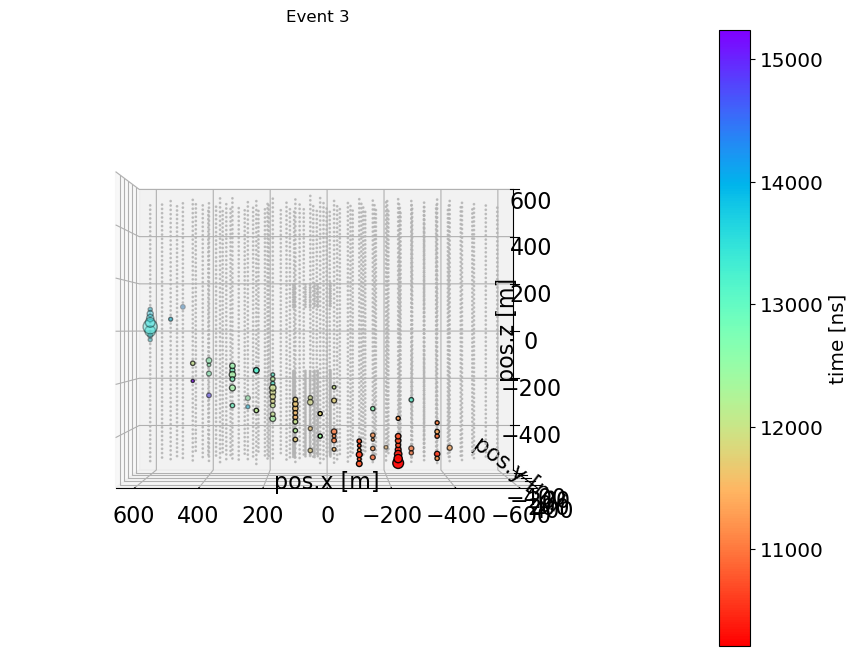

In [7]:
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'
geo = pd.read_csv(geo_file)

events_meta_file = os.path.join(PATH_TO_INPUT, META_FILE_NAME)
events_pulses_file = os.path.join(PATH_TO_INPUT, PULSES_FILE_NAME)
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'

events_meta = pd.read_feather(events_meta_file)
events_data = pd.read_feather(events_pulses_file)
geo = pd.read_csv(geo_file)


int_cols_meta = ["event_id", "idx_start", "idx_end", "n_channel_HLC", "n_channel"]
events_meta[int_cols_meta] = events_meta[int_cols_meta].astype("Int64")

int_cols_data = ["event_id", "sensor_id", "is_HLC"]
events_data[int_cols_data] = events_data[int_cols_data].astype("Int64")

meta, pulses = get_event_data(EVENT_INDEX, events_meta, events_data)
print(f"muon energy: {meta['muon_energy_at_detector']/1.e3:.1f} TeV")

# Get dom locations, first hit times, and total charges (for each dom).
event_data = get_per_dom_summary_from_sim_data(meta, pulses, geo)
print("length of event data:", len(event_data))
print("length of pulses data:", len(pulses))
# Remove early pulses.
replace_early_pulse(event_data, pulses)
print("n_doms", len(event_data))

# Get MCTruth.
true_pos = jnp.array([meta['muon_pos_x'], meta['muon_pos_y'], meta['muon_pos_z']])
print(true_pos)
true_time = meta['muon_time']
true_zenith = meta['muon_zenith']
true_azimuth = meta['muon_azimuth']
true_src = jnp.array([true_zenith, true_azimuth])
true_src_deg = np.rad2deg(true_src)
print("true direction:", true_src)
print("true direction:", true_src_deg)
print("length of event data:", len(event_data))
splinempe_zenith = meta['spline_mpe_zenith']
splinempe_azimuth = meta['spline_mpe_azimuth']
spline_src = jnp.array([splinempe_zenith, splinempe_azimuth])

plot_event(event_data, EVENT_INDEX, geo=geo)

/mnt/scratch/baburish/TPN-training/final/TPN_God/helpers.py:529: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=12)


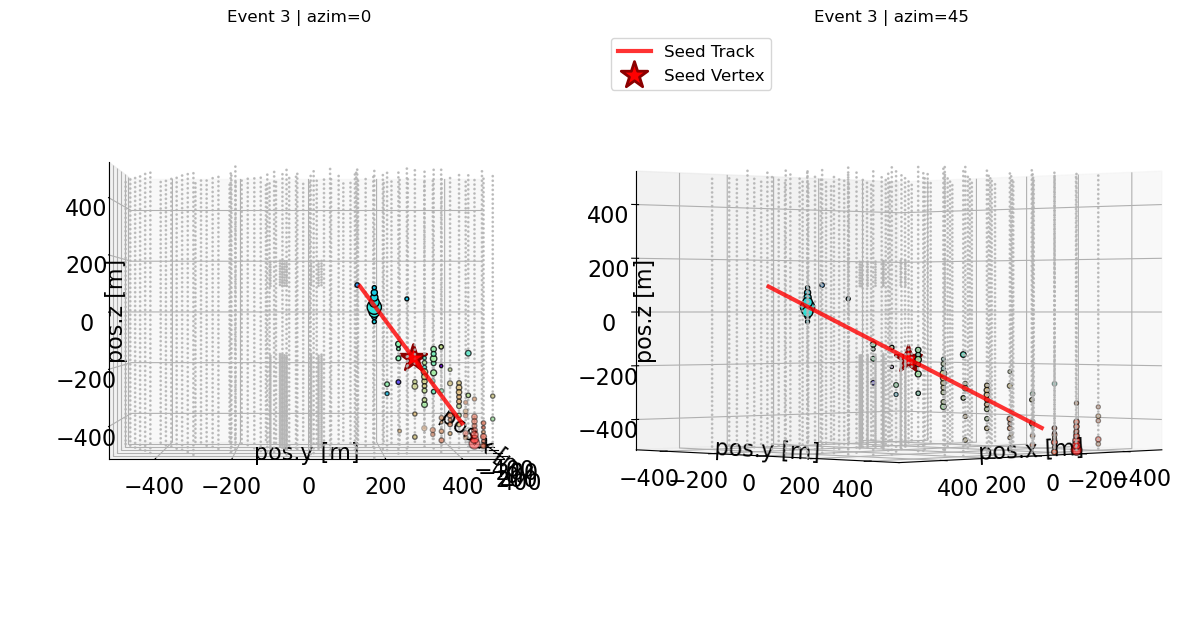

In [8]:
seed_pos, seed_time, _, seed_src = linefit(event_data)
seed_pos  = jnp.asarray(seed_pos)      # (3,)
seed_time = jnp.asarray(seed_time)     # scalar ()
seed_src  = jnp.asarray(seed_src)      # (2,)



plot_event_new(event_data, EVENT_INDEX, geo=geo, seed_pos=seed_pos, seed_time=seed_time, seed_direction=seed_src, track_length=1000, azims=(0, 45), elev=0)

In [9]:
network_path = '/mnt/scratch/baburish/TPN-training/gupta_mixture_jax/new_weights/4comp_no_penalties_w4096batch_tree_start_epoch_255.eqx'
eval_network_v = get_network_eval_v_fn_f32(bpath=network_path, dtype=dtype, n_hidden=n_hidden)
eval_network_doms_and_track = get_eval_network_doms_and_track(eval_network_v, dtype=dtype, gupta=gupta, n_comp=n_comp)


shifting seed vertex.

Starting fit with Gaussian convolution width: 3 ns
Initial fit: logl 916.815
Sigma 3: 4.20s
Linefit direction: [119.98874867 159.90391217] deg
Reconstructed vs True Angular Distance error 2.61 deg
SplineMPE vs True Angular Distance error 0.09 deg
running the scan.

Likelihood at best_direction: 913.515006
ΔlogL at best_direction: 0.182295

Likelihood at spline_src: 913.428638
ΔlogL at spline_src: 0.095927


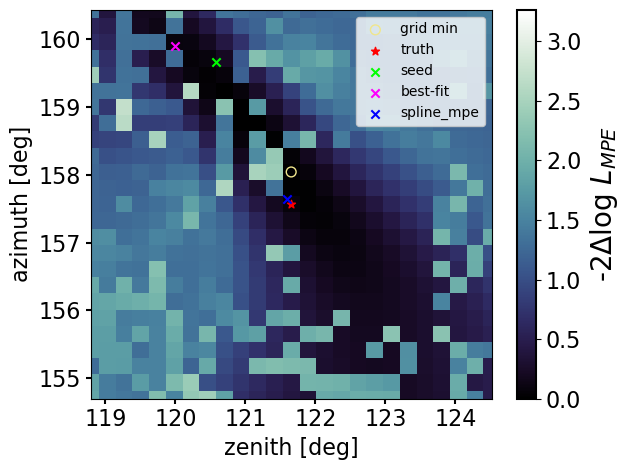

In [13]:
track_pos, track_time, _, track_src = linefit(event_data)
track_pos  = jnp.asarray(track_pos)      # (3,)
track_time = jnp.asarray(track_time)     # scalar ()
track_src  = jnp.asarray(track_src)      # (2,)

# print("original seed vertex:", np.rad2deg(true_src), "m")
# print("seed direction:", np.rad2deg(track_src), "deg")
# print("Weighted vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(track_src[0]))**2+(true_src_deg[1]-np.rad2deg(track_src[1]))**2))
# print("spline_mpe position:", jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']]))
# print("spline_mpe time:", meta['spline_mpe_time'])


center_track_seed = True

centered_track_pos, centered_track_time = track_pos, track_time
if center_track_seed:
    print("shifting seed vertex.")
    centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)

# print("seed vertex:", centered_track_pos, "m")

fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
# print(fitting_event_data.shape)


# GAUS_CONV_WIDTH = [100, 10, 3]
GAUS_CONV_WIDTH = [3]
best_logl = None
t_total_warm = 0
best_logl = None
sigma_times_warm = []
start = time.time()
for sigma in GAUS_CONV_WIDTH:
    print(f"\nStarting fit with Gaussian convolution width: {sigma} ns")
    neg_llh = get_neg_c_triple_gamma_llh_SRT_noise(eval_network_doms_and_track, sigma=sigma)
    fit_llh = get_fitter(neg_llh, use_multiple_vertex_seeds=False, prescan_time=False)#, rtol=1e-16, atol=1e-14)
    fit_llh_jit = jax.jit(fit_llh)
    
    if best_logl is not None:
        seed_src = best_direction
        seed_pos = best_vertex
        seed_time = best_time
    else:
        seed_src = track_src
        seed_pos = centered_track_pos
        seed_time = centered_track_time
    
    solution = fit_llh_jit(seed_src, seed_pos, seed_time, fitting_event_data)
    current_logl, current_direction, current_vertex, current_time = solution

    if best_logl is None:
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
        accepted = True
        print(f"Initial fit: logl {current_logl:.3f}")
        continue  

    delta_logl = -2*(current_logl - best_logl)
    if meta['q_tot'] > 100:
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
    else:
        if sigma <= 2:
            best_logl = current_logl
            best_direction = current_direction
            best_vertex = current_vertex
            best_time = current_time
            accepted = True
        elif delta_logl > 9:  # 90% confidence improvement threshold for 2 dof
            best_logl = current_logl
            best_direction = current_direction
            best_vertex = current_vertex
            best_time = current_time
            accepted = True
            print(f"Accepted update: logl improved by {delta_logl:.3f}")

        else:
            print(f"Rejected update: logl improved by {delta_logl:.3f}")
            accepted = False
    

elapsed = time.time() - start
print(f"Sigma {sigma}: {elapsed:.2f}s")
linefit_best_direction = np.array(np.rad2deg(best_direction))
linefit_seed_direction = np.rad2deg(seed_src)
spline_src_deg = np.rad2deg(spline_src)
best_direction_deg = np.rad2deg(best_direction)
spline_src_deg = np.rad2deg(spline_src)
linefit_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    best_direction_deg[0], best_direction_deg[1]
)
splinempe_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    spline_src_deg[0], spline_src_deg[1]
)
print("Linefit direction:", linefit_best_direction, "deg")
print(f"Reconstructed vs True Angular Distance error {linefit_ang_err:.2f} deg")
print(f"SplineMPE vs True Angular Distance error {splinempe_ang_err:.2f} deg")


scan_llh = get_scanner(
                        neg_llh,
                        use_multiple_vertex_seeds=True,
                        prescan_time=False,
                        n_splits=25,
                        use_jit=True
                    )

zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
X, Y = jnp.meshgrid(zenith, azimuth)
fig, ax = plt.subplots()

plot_scan = True
if plot_scan:
    print("running the scan.")
    solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)

    sol_logl, sol_vertex, sol_time = solution
    logls = sol_logl.reshape(X.shape)
    points = np.column_stack([X.flatten(), Y.flatten()])
    values = logls.flatten()
    logl_best_dir = griddata(points, values, 
                             (best_direction[0], best_direction[1]), 
                             method='cubic')
    delta_logl_best_dir = logl_best_dir - np.amin(logls)
    logl_spline = griddata(points, values, 
                          (spline_src[0], spline_src[1]), 
                          method='cubic')
    delta_logl_spline = logl_spline - np.amin(logls)
    
    print(f"\nLikelihood at best_direction: {logl_best_dir:.6f}")
    print(f"ΔlogL at best_direction: {delta_logl_best_dir:.6f}")
    print(f"\nLikelihood at spline_src: {logl_spline:.6f}")
    print(f"ΔlogL at spline_src: {delta_logl_spline:.6f}")
    # Plot.

    min_logl = np.amin(logls)
    delta_logl = logls - np.amin(logls)
    # pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
    pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=1.2*np.amax(delta_logl), shading='auto', cmap=cx)
    cbar = fig.colorbar(pc)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.get_yaxis().labelpad = 5
    cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
    cbar.outline.set_linewidth(1.5)

    contours = [4.61]
    ix1, ix2 = np.where(delta_logl==0)
    ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
    ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)
ax.scatter(np.rad2deg(spline_src[0]), np.rad2deg(spline_src[1]), marker="x", color='blue', label="spline_mpe", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))

ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
plt.legend()
plt.tight_layout()

plt.show()


In [11]:
linefit_best_direction = np.rad2deg(best_direction)
linefit_best_direction =[linefit_best_direction[0], linefit_best_direction[1]]
print("Linefit direction:", linefit_best_direction, "deg")



Linefit direction: [119.98874866719186, 159.90391216916208] deg
